# Backtesting

As a result of my exploration in `stock-selection.ipynb` and `clustering.ipynb`, I have come to a final selection of stocks that are based on the real estate industry and REIT-Residential sector from Yahoo Finance. Using these stocks I conducted a manual backtest.

## 1. Download data

In [420]:
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

FINAL_TICKERS = ["AMH", "AVB", "CPT", "ELS", "EQR", "IRT", "MAA", "SUI", "UDR", "UMH"]

end_date = dt.datetime.now().strftime('%Y-%m-%d')
start_date = (pd.to_datetime(end_date) - pd.DateOffset(365*12)).strftime('%Y-%m-%d')
df = yf.download(FINAL_TICKERS, start=start_date, end=end_date, auto_adjust=True)['Close']


df = df.dropna(axis=1)

print('df size: ', df.shape)

[*********************100%***********************]  10 of 10 completed

df size:  (3014, 10)


## 2. Implement Strategy

For my first strategy, we will implement single cluster mean reversion. This strategy was taken from [151 Trading Strategies](https://ssrn.com/abstract=3247865) page 46-47. The functions have all been implemented in `backtest.py` as I need to reuse them later in `meta-labelling.ipynb`

In [ ]:
from backtest import print_stats, run_benchmark, run_backtest

## 3. Backtesting

### 3.1 Full backtest

Running the strategy on ALL of the downloaded data (~12 years) with no transaction cost

--- Strategy ---
Total return: 178.51%
Sharpe ratio: 1.28
Max drawdown: -8.56%
--- Benchmark ---
Total return: 190.65%
Sharpe ratio: 0.51
Max drawdown: -39.51%


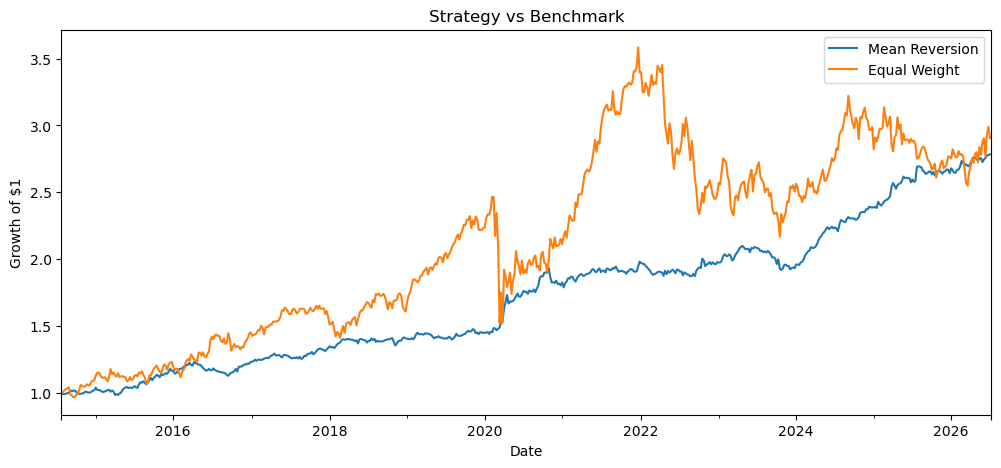

In [403]:
end = df.index.max()
start = df.index.min()

strategy = run_backtest(df, start_date=start, end_date=end, cost_bps=0)
benchmark = run_benchmark(df, start_date=start, end_date=end)

print("--- Strategy ---")
print_stats(strategy["stats"])

print("--- Benchmark ---")
print_stats(benchmark["stats"])


equity = strategy["equity"]
cluster_equity = benchmark["equity"]

plt.figure(figsize=(12, 5))
(equity / equity.iloc[0]).plot(label="Mean Reversion")
(cluster_equity / cluster_equity.iloc[0]).plot(label="Equal Weight")
plt.legend()
plt.ylabel("Growth of $1")
plt.title("Strategy vs Benchmark")
plt.show()

### 3.2 Backtest on multiple time periods

To ensure that the results of the algorithm are consistent during different time periods, I tested the strategy on four 3 year periods throughout the 12 years of data.

---- 2014-07-14 00:00:00 to 2017-07-14 00:00:00 ----
--- Strategy ---
Total return: 26.22%
Sharpe ratio: 1.20
Max drawdown: -8.33%
--- Benchmark ---
Total return: 59.07%
Sharpe ratio: 1.10
Max drawdown: -9.44%


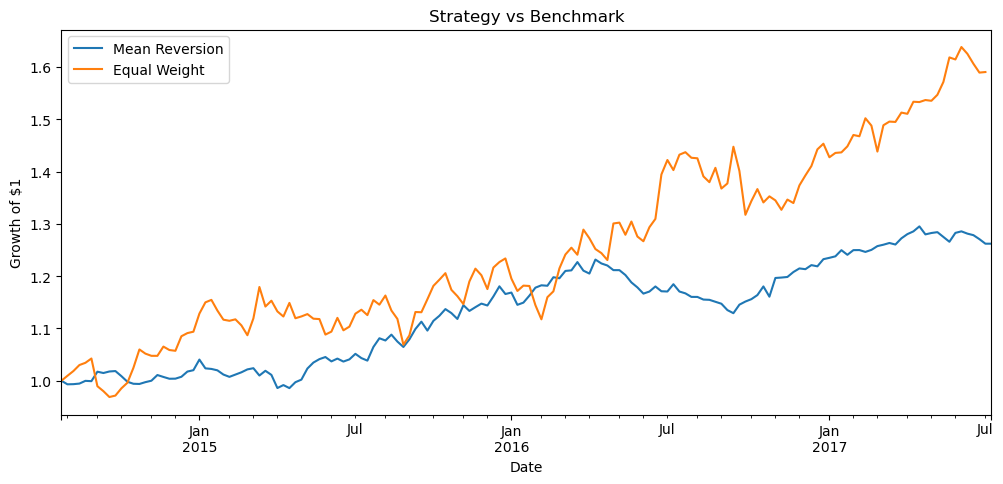

---- 2017-07-14 00:00:00 to 2020-07-14 00:00:00 ----
--- Strategy ---
Total return: 39.90%
Sharpe ratio: 1.55
Max drawdown: -3.92%
--- Benchmark ---
Total return: 17.53%
Sharpe ratio: 0.34
Max drawdown: -38.24%


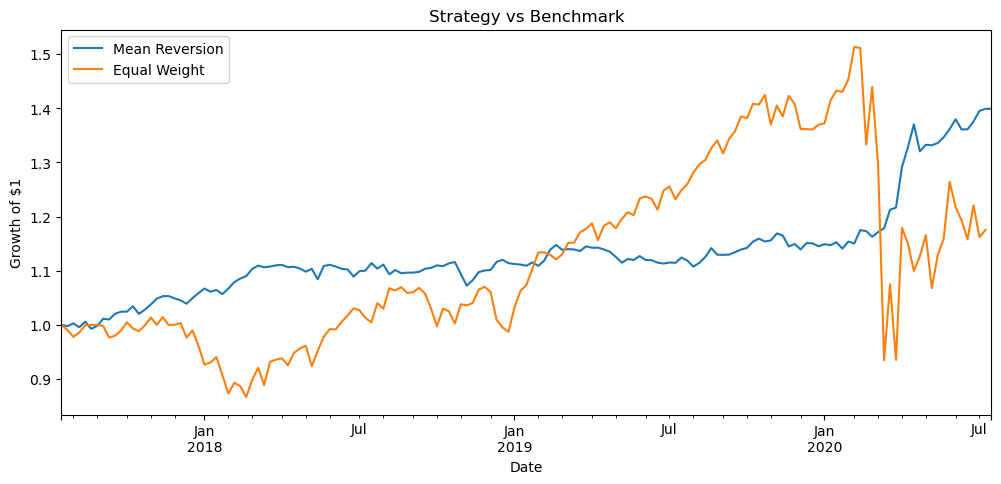

---- 2020-07-14 00:00:00 to 2023-07-14 00:00:00 ----
--- Strategy ---
Total return: 19.60%
Sharpe ratio: 0.83
Max drawdown: -7.49%
--- Benchmark ---
Total return: 37.12%
Sharpe ratio: 0.66
Max drawdown: -35.04%


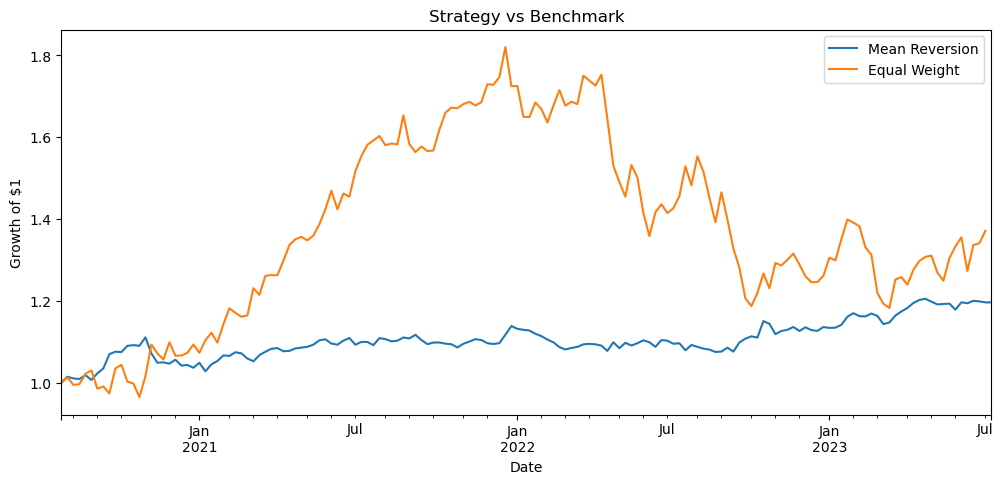

---- 2023-07-14 00:00:00 to 2026-07-08 00:00:00 ----
--- Strategy ---
Total return: 35.13%
Sharpe ratio: 1.62
Max drawdown: -6.96%
--- Benchmark ---
Total return: 11.00%
Sharpe ratio: 0.21
Max drawdown: -20.81%


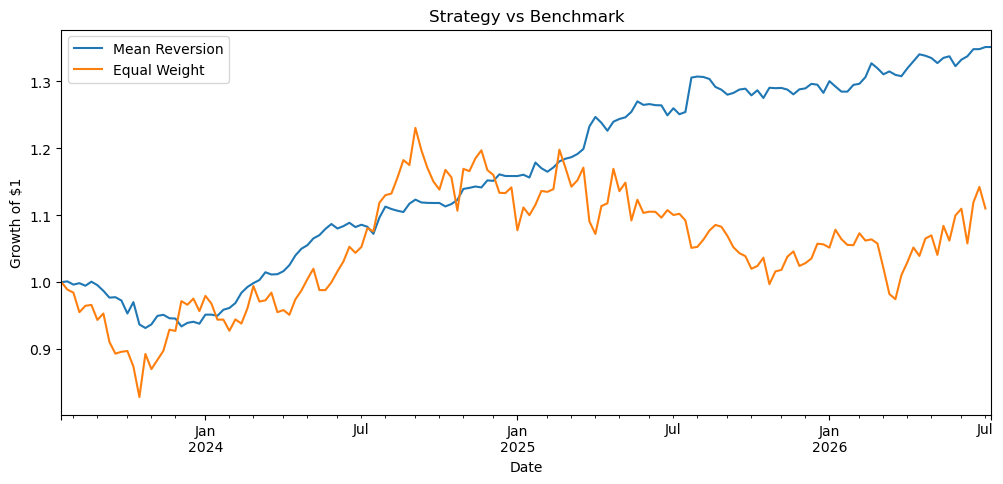

In [ ]:
periods = [
    (start, start + pd.DateOffset(years=3)),
    (start + pd.DateOffset(years=3), start + pd.DateOffset(years=6)),
    (start + pd.DateOffset(years=6), start + pd.DateOffset(years=9)),
    (start + pd.DateOffset(years=9), end),
]

for s, e in periods:
    print(f"---- {s} to {e} ----")
    strategy = run_backtest(df, start_date=s, end_date=e, cost_bps=0)
    benchmark = run_benchmark(df, start_date=s, end_date=e)

    print("--- Strategy ---")
    print_stats(strategy["stats"])

    print("--- Benchmark ---")
    print_stats(benchmark["stats"])


    equity = strategy["equity"]
    cluster_equity = benchmark["equity"]

    plt.figure(figsize=(12, 5))
    (equity / equity.iloc[0]).plot(label="Mean Reversion")
    (cluster_equity / cluster_equity.iloc[0]).plot(label="Equal Weight")
    plt.legend()
    plt.ylabel("Growth of $1")
    plt.title("Strategy vs Benchmark")
    plt.show()


#### Conclusion

The algorithm performed well on three periods out of the 4, with the 2014-2017, 2017-2020 and 2023-2026 time periods having an average Sharpe Ratio of ~1.45. However, during the 2020-2023 period the Sharpe Ratio dropped below 1 to around 0.8. This suggests the strategy is generally robust across several regimes, but may be less effective during economic uncertainty.

### 3.3 Leave-one-out backtest
This backtest tests the stock cluster for overreliance on one specific stock. For each stock in the cluster, we remove it and run the algorithm on the remaining stocks. If removing any of the one stocks from the cluster significantly reduces the algorithm's result, then the strategy likely depends on that one stock. These were tested on the last three years of data.

--- Strategy ---
Total return: 173.10%
Sharpe ratio: 1.18
Max drawdown: -10.12%
--- Benchmark ---
Total return: 194.99%
Sharpe ratio: 0.51
Max drawdown: -41.04%


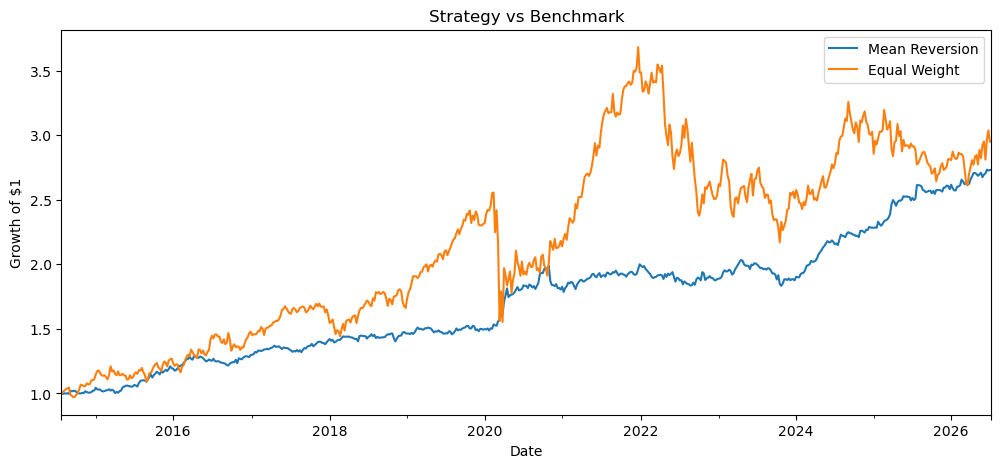

--- Strategy ---
Total return: 181.34%
Sharpe ratio: 1.25
Max drawdown: -9.75%
--- Benchmark ---
Total return: 202.85%
Sharpe ratio: 0.53
Max drawdown: -40.40%


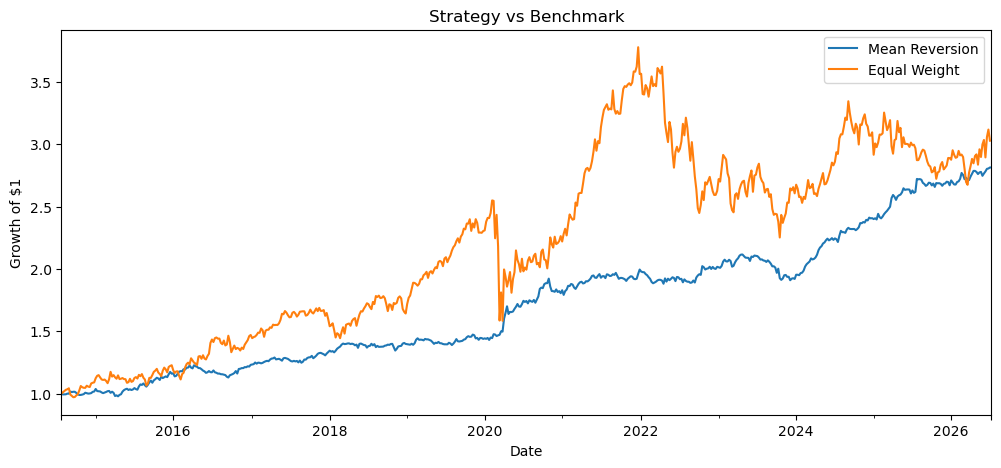

--- Strategy ---
Total return: 185.10%
Sharpe ratio: 1.23
Max drawdown: -9.29%
--- Benchmark ---
Total return: 193.64%
Sharpe ratio: 0.51
Max drawdown: -38.25%


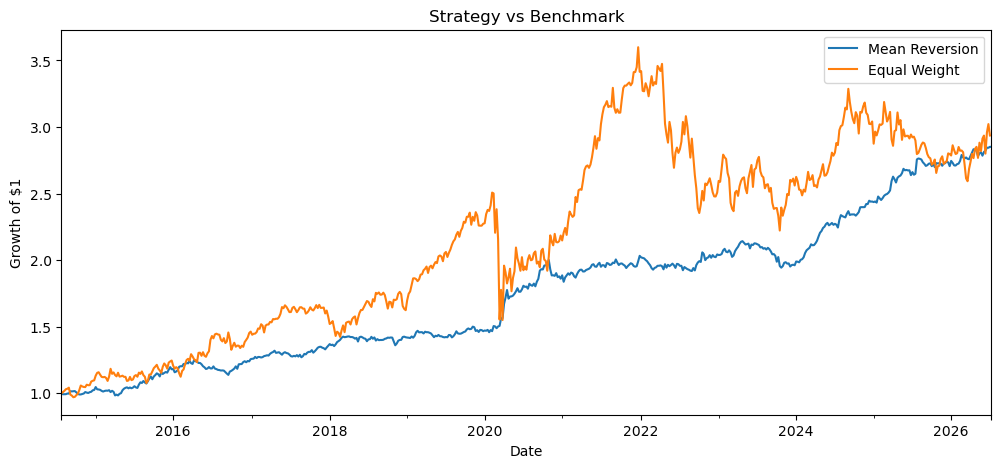

--- Strategy ---
Total return: 169.48%
Sharpe ratio: 1.20
Max drawdown: -10.68%
--- Benchmark ---
Total return: 177.87%
Sharpe ratio: 0.49
Max drawdown: -41.23%


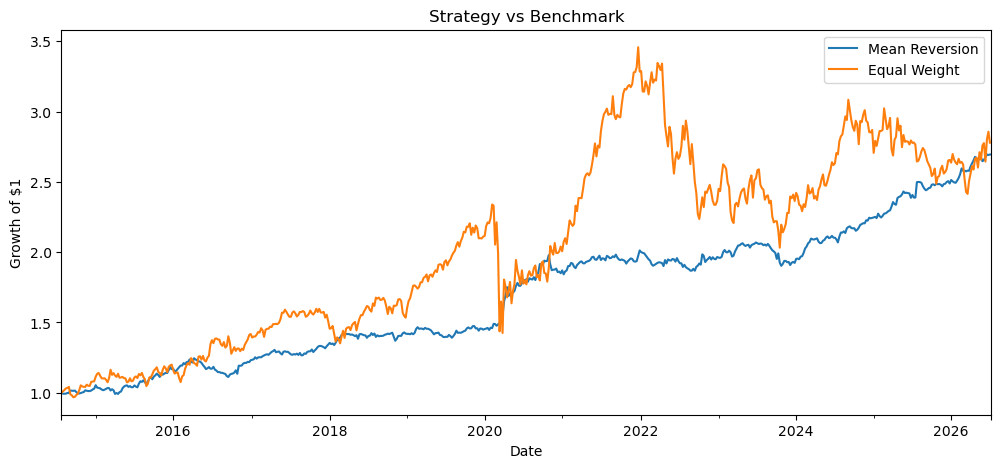

--- Strategy ---
Total return: 214.84%
Sharpe ratio: 1.39
Max drawdown: -9.17%
--- Benchmark ---
Total return: 202.20%
Sharpe ratio: 0.53
Max drawdown: -39.97%


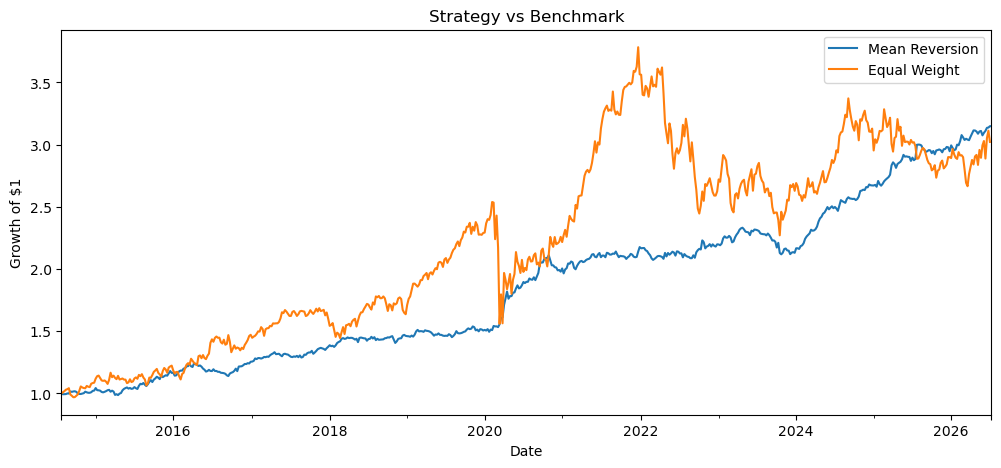

--- Strategy ---
Total return: 123.85%
Sharpe ratio: 1.02
Max drawdown: -8.60%
--- Benchmark ---
Total return: 179.92%
Sharpe ratio: 0.50
Max drawdown: -38.41%


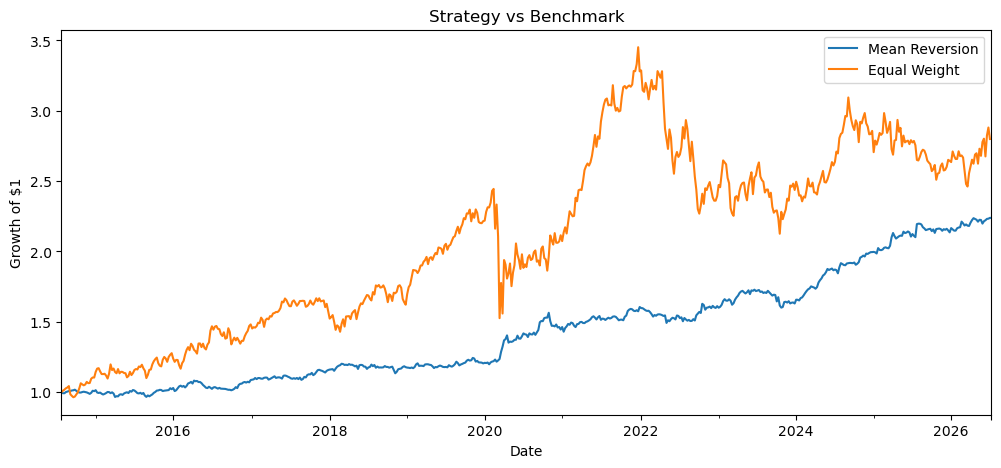

--- Strategy ---
Total return: 185.46%
Sharpe ratio: 1.25
Max drawdown: -9.45%
--- Benchmark ---
Total return: 187.77%
Sharpe ratio: 0.51
Max drawdown: -38.86%


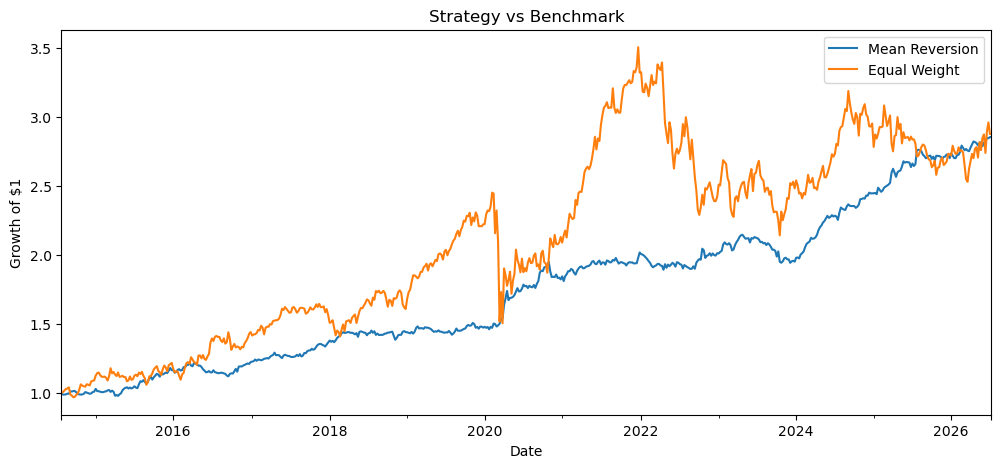

--- Strategy ---
Total return: 161.06%
Sharpe ratio: 1.18
Max drawdown: -10.42%
--- Benchmark ---
Total return: 182.18%
Sharpe ratio: 0.50
Max drawdown: -38.92%


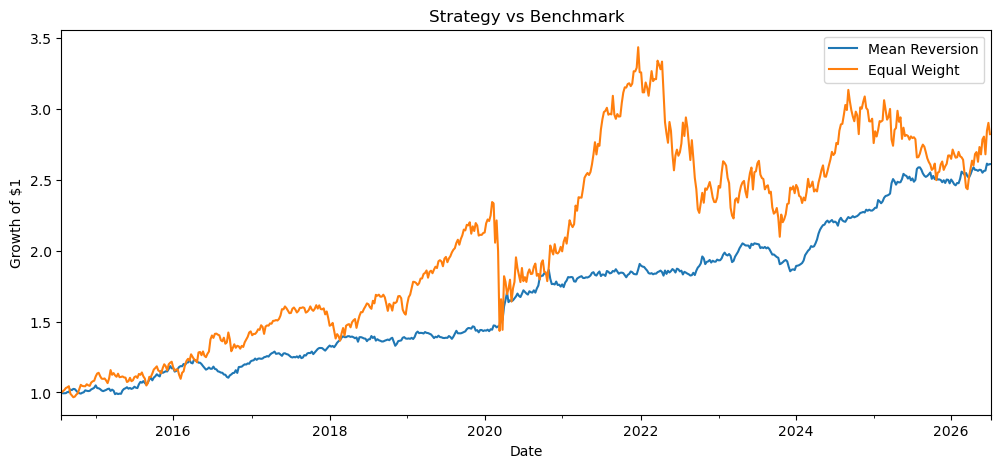

--- Strategy ---
Total return: 188.20%
Sharpe ratio: 1.29
Max drawdown: -8.89%
--- Benchmark ---
Total return: 199.46%
Sharpe ratio: 0.52
Max drawdown: -39.11%


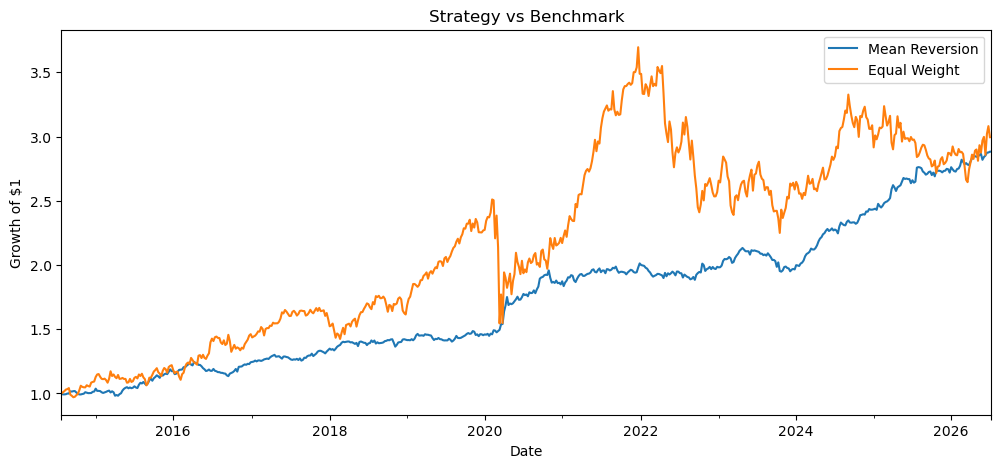

--- Strategy ---
Total return: 136.64%
Sharpe ratio: 1.04
Max drawdown: -9.20%
--- Benchmark ---
Total return: 183.61%
Sharpe ratio: 0.50
Max drawdown: -38.87%


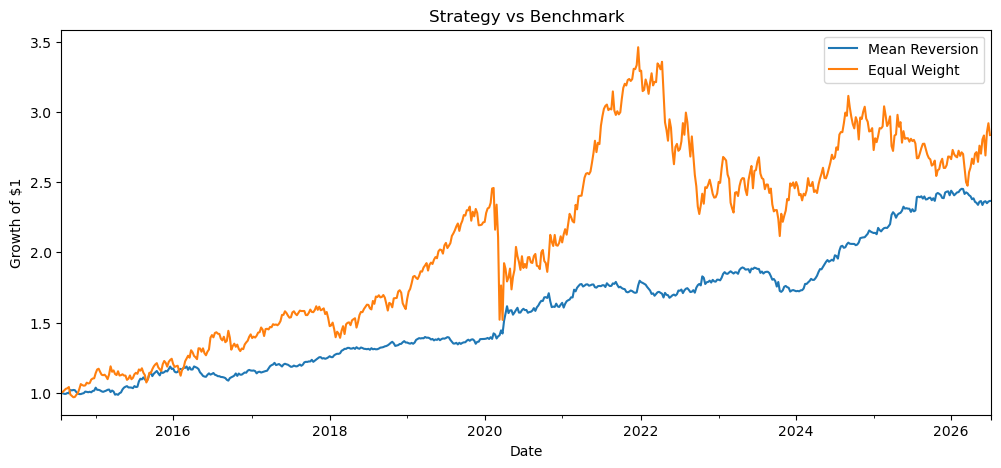

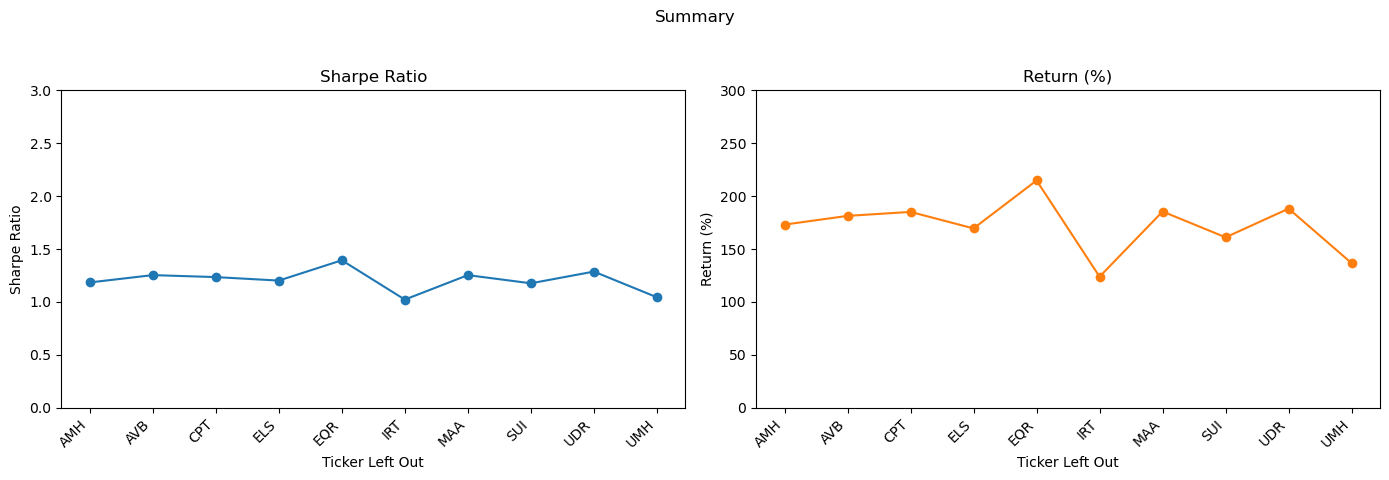

In [418]:
end = df.index.max()
start = end - pd.DateOffset(years=12)

sharpe_ratios = []
returns = []

for i in range(len(FINAL_TICKERS)):
    ticker = FINAL_TICKERS[i]
    df_no_ticker = df.drop(columns=[ticker])
    strategy = run_backtest(df_no_ticker, start_date=start, end_date=end, cost_bps=0)
    benchmark = run_benchmark(df_no_ticker, start_date=start, end_date=end)

    sharpe_ratios.append(strategy["stats"]["sharpe"])
    returns.append(strategy["stats"]["total_return_pct"])

    print("--- Strategy ---")
    print_stats(strategy["stats"])

    print("--- Benchmark ---")
    print_stats(benchmark["stats"])


    equity = strategy["equity"]
    cluster_equity = benchmark["equity"]

    plt.figure(figsize=(12, 5))
    (equity / equity.iloc[0]).plot(label="Mean Reversion")
    (cluster_equity / cluster_equity.iloc[0]).plot(label="Equal Weight")
    plt.legend()
    plt.ylabel("Growth of $1")
    plt.title("Strategy vs Benchmark")
    plt.show()


# Plot the Sharpe Ratio and the Return
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Summary")

leaveout_labels = FINAL_TICKERS

axs[0].plot(leaveout_labels, sharpe_ratios, marker='o', linestyle='-')
axs[0].set_title("Sharpe Ratio")
axs[0].set_xlabel("Ticker Left Out")
axs[0].set_ylabel("Sharpe Ratio")
axs[0].set_ylim(bottom=0, top=3)
axs[0].set_xticks(range(len(leaveout_labels)))
axs[0].set_xticklabels(leaveout_labels, rotation=45, ha='right')

axs[1].plot(leaveout_labels, returns, marker='o', color='tab:orange', linestyle='-')
axs[1].set_title("Return (%)")
axs[1].set_xlabel("Ticker Left Out")
axs[1].set_ylabel("Return (%)")
axs[1].set_ylim(bottom=0, top=300)
axs[1].set_xticks(range(len(leaveout_labels)))
axs[1].set_xticklabels(leaveout_labels, rotation=45, ha='right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### Conclusion

From the results it is clear that the strategy doesn't rely on any one stock in particular, as no matter which stock was removed, the strategy maintained a Sharpe Ratio of around 1.0-1.5, and a return of around 150-200%. 

It is worth noting that the removal of EQR improved the Sharpe Ratio and Return, whereas the removal of IRT decreased both the return and Sharpe Ratio, which could mean that IRT is one of the more important stocks in the cluster, whereas EQR is a stock that worses the performance of the cluster on average.

### 3.4 Backtest with transaction cost
My strategy has to rebalance every single week, therefore the transaction costs will add up. In order to find out how much the various transaction costs will hurt the strategy, I will test out the values 0.05%, 0.10% and 0.2%.

In [ ]:
end = df.index.max() - pd.DateOffset(years=4)
start = end - pd.DateOffset(years=12)

cost = [5, 10, 20]

for c in cost:
    strategy = run_backtest(df, start_date=start, end_date=end, cost_bps=c)
    benchmark = run_benchmark(df, start_date=start, end_date=end)

    print("--- Strategy ---")
    print_stats(strategy["stats"])

    print("--- Benchmark ---")
    print_stats(benchmark["stats"])


    equity = strategy["equity"]
    cluster_equity = benchmark["equity"]

    plt.figure(figsize=(12, 5))
    (equity / equity.iloc[0]).plot(label="Mean Reversion")
    (cluster_equity / cluster_equity.iloc[0]).plot(label="Equal Weight")
    plt.legend()
    plt.ylabel("Growth of $1")
    plt.title("Strategy vs Benchmark")
    plt.show()

NameError: name 'df' is not defined

#### Conclusion
When the transaction cost was 5bps, the algorithm performed slightly worse but still tolerable. However, at 10 and 20 bps it was significantly underperforming the very basic equal weight buy and hold strategy. This is expected, as the current strategy as it is rebalances every single week, so the transaction costs add up. This provides a good motivation for meta-labelling, as we will train a machine learning model to selectively pick out which trades to take, which should not only boost the strategy's effectiviness, but also its cost tolerance.